In [38]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import numpy as np

In [74]:
base_path = 'data/Classcification'
train_dir = f'{base_path}/train'
test_dir = f'{base_path}/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32, class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=32, class_mode='categorical'
)

Found 474 images belonging to 7 classes.


Found 486 images belonging to 7 classes.


In [75]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

base_model.trainable = False
for layer in base_model.layers[:-50] :
    layer.trainable = False


model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

In [76]:
model.compile(
    optimizer=Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

In [77]:
epochs = 20
history = model.fit(
    train_generator,
    validation_data = test_generator,
    epochs = epochs
)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.3207 - loss: 1.7368 - val_accuracy: 0.5247 - val_loss: 1.4760
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 798ms/step - accuracy: 0.5443 - loss: 1.3806 - val_accuracy: 0.6358 - val_loss: 1.1901
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 763ms/step - accuracy: 0.6055 - loss: 1.1549 - val_accuracy: 0.6914 - val_loss: 1.0221
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 757ms/step - accuracy: 0.6646 - loss: 0.9914 - val_accuracy: 0.7099 - val_loss: 0.9167
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 759ms/step - accuracy: 0.7089 - loss: 0.9120 - val_accuracy: 0.7510 - val_loss: 0.8343
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 771ms/step - accuracy: 0.7215 - loss: 0.8544 - val_accuracy: 0.7572 - val_loss: 0.7862
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 768ms/step - accuracy: 0.7384 - loss: 0.7638 - val_accuracy: 0.7798 - val_loss: 0.7307
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 758ms/step - accuracy: 0.7215 - loss: 0.7763 - val_accurac

In [ ]:
model.save('model/clouds-classification_final.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


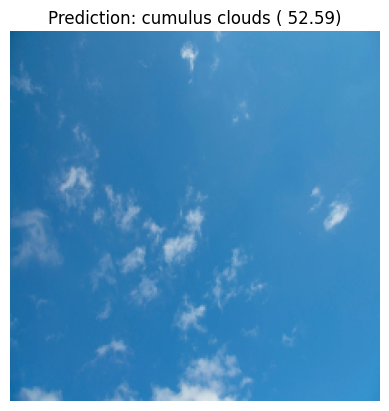

In [84]:
img_path = 'sky-105.jpg'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

predictions = model.predict(img_array)
class_indices = train_generator.class_indices
labels = {v : k for k, v in class_indices.items()}

predicted_class = labels[np.argmax(predictions)]
confidence = np.max(predictions) * 100

plt.imshow(img)
plt.title(f"Prediction: {predicted_class} ({confidence : .2f})")
plt.axis('off')
plt.show()